In [18]:
from scipy.signal import butter, filtfilt, find_peaks
import neurokit2 as nk
import numpy as np
import pyxdf
import matplotlib.pyplot as plt
import pandas as pd
from biosppy.signals.ppg import ppg

In [36]:
#streams, header = pyxdf.load_xdf("Test_Data/sub-ert_ses-1_task-Baseline_.xdf")
streams, header = pyxdf.load_xdf("Test_Data/sub-Pilot 2_ses-1_task-Baseline_.xdf")

bvp_stream = next(s for s in streams
                  if s["info"]["name"][0] == "OpenSignals")

# time_series is an N×2 array: [nSeq, BVP0]
bvp_data      = bvp_stream["time_series"][:, 1]       # relative-intensity BVP
bvp_timestamps = bvp_stream["time_stamps"]           # in seconds (LSL clock)

marker_stream = next(s for s in streams
                     if s["info"]["name"][0] == "UnityMarkers")

marker_times  = marker_stream["time_stamps"]
marker_values = [m[0] for m in marker_stream["time_series"]]
# marker_values will be strings like "DrinkCompleted" or custom Unity event labels


          time          event       BVP
0  4948.094649  BaselineStart  0.526541


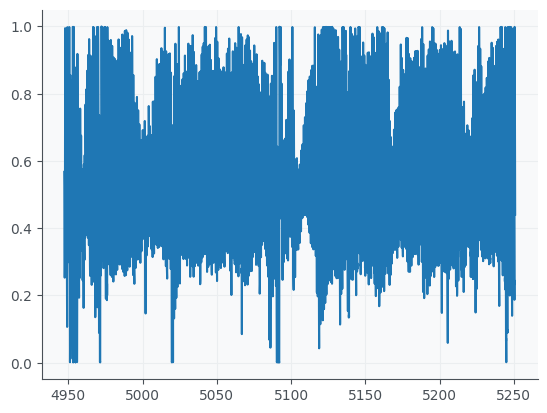

In [37]:
bvp_s   = next(s for s in streams if s["info"]["name"][0] == "OpenSignals")
mark_s  = next(s for s in streams if s["info"]["name"][0] == "UnityMarkers")

# 3. Pull out data & times
bvp, bvp_ts   = bvp_s["time_series"][:,1], bvp_s["time_stamps"]
marks, mark_ts = [m[0] for m in mark_s["time_series"]], mark_s["time_stamps"]

# 4. Build pandas DataFrame for easy merging
df_bvp    = pd.DataFrame({"time": bvp_ts, "BVP": bvp})
df_events = pd.DataFrame({"time": mark_ts, "event": marks})

# 5. (example) merge asof to tag each event with last BVP sample
df_merged = pd.merge_asof(df_events.sort_values("time"),
                          df_bvp.sort_values("time"),
                          on="time", direction="backward")

print(df_merged)
plt.plot(bvp_ts, bvp)


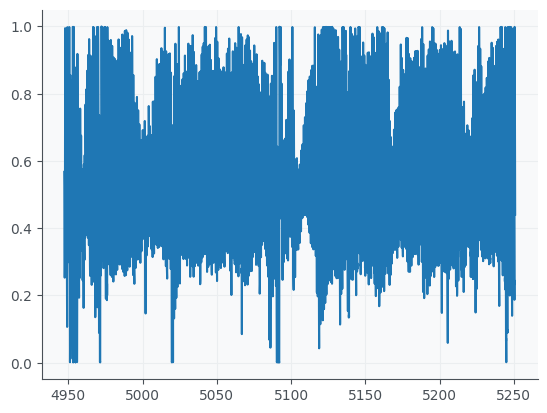

In [39]:
# Find the stream whose name matches your OpenSignals/BVP sensor
bvp_stream = None
for s in streams:
    name = s['info']['name'][0]
    desc  = s['info']['desc'][0]['channels'][0]['channel']
    labels = [ch['label'][0] for ch in desc]
    if name == "OpenSignals" and "BVP0" in labels:
        bvp_stream = s
        break

if bvp_stream is None:
    raise RuntimeError("Could not find BVP0 stream in XDF file.")

# Data is a N×C ndarray of float32, timestamps is length-N
data       = bvp_stream['time_series']     # shape (N, 2)
timestamps = bvp_stream['time_stamps']     # shape (N,)

# Channel 0 is nSeq (frame counter), channel 1 is BVP0
bvp_signal = data[:, 1].astype(np.float64)
time_s     = np.array(timestamps)          # in seconds since session start

plt.plot(time_s, bvp_signal)
nominal_srate = 400

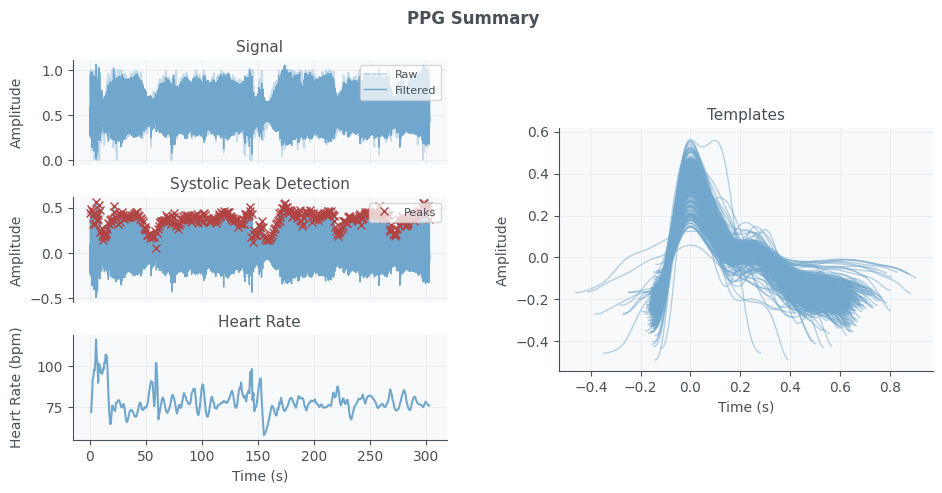

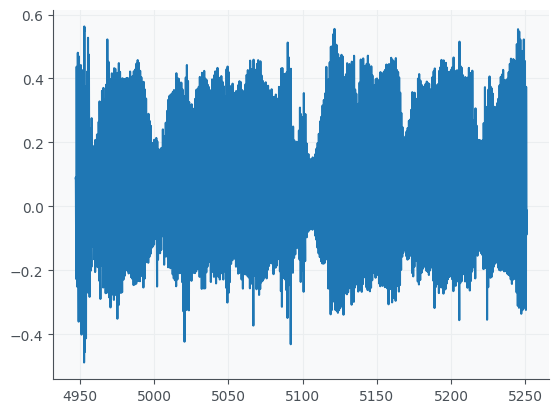

In [ ]:
# 4th order butterworth bandpass filter at 0.5-8 Hz
b, a = butter(4, [0.5/  (nominal_srate / 2),
                   8 / (nominal_srate / 2)],
                   btype='bandpass')
filtered_signal = filtfilt(b, a, bvp_signal)

# peaks are marked as 1
#signals, info = nk.ppg_process(bvp_signal, sampling_rate=nominal_srate)
#print(signals)

# Get the peaks
ts, filtered_signal, peaks, _, _, hr_ts, heart_rate = ppg(bvp_signal, sampling_rate=nominal_srate, show=True)

peak_times = peaks / nominal_srate
ibi = np.diff(peak_times) * 1000  # convert to ms


In [41]:
hrv_metrics = nk.hrv({'RRI': ibi, 'RRI_Time': peak_times[1:]}, sampling_rate=1000)

print(hrv_metrics)

   HRV_MeanNN   HRV_SDNN  HRV_SDANN1  HRV_SDNNI1  HRV_SDANN2  HRV_SDNNI2  \
0  768.083756  74.488984   17.233789   66.242695    9.484464    65.31986   

   HRV_SDANN5  HRV_SDNNI5  HRV_RMSSD   HRV_SDSD  ...  HRV_SampEn  HRV_ShanEn  \
0         NaN         NaN  55.422418  55.493064  ...    1.180978     7.43433   

   HRV_FuzzyEn  HRV_MSEn  HRV_CMSEn  HRV_RCMSEn   HRV_CD   HRV_HFD   HRV_KFD  \
0     0.812264  0.968085   1.250295    1.758136  1.39974  1.674753  2.557264   

    HRV_LZC  
0  0.787802  

[1 rows x 91 columns]
